In [18]:
import numpy as np
from scipy.integrate import solve_ivp

step = 100


x = np.linspace(0, 1, step)
x_step = 1/step


def d2(u):
    u = np.concatenate([np.array(u[:1]), u,np.array(u[-1:])])
    return (u[2:] + u[:-2] + -2*u[1:-1])/x_step ** 2

def dxdxu(t, u):
    return d2(u)

def udxdxu(t, u):
    return u*d2(u)

def uudxdxu(t, u): 
    return u**2*d2(u)

y0 = np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)

r = [0, 0.1]
e = np.array(range(101))/1000

y_0 = solve_ivp(dxdxu, r, y0, t_eval = e)
y_1 = solve_ivp(udxdxu, r, y0, t_eval = e)
y_2 = solve_ivp(uudxdxu, r, y0, t_eval = e)

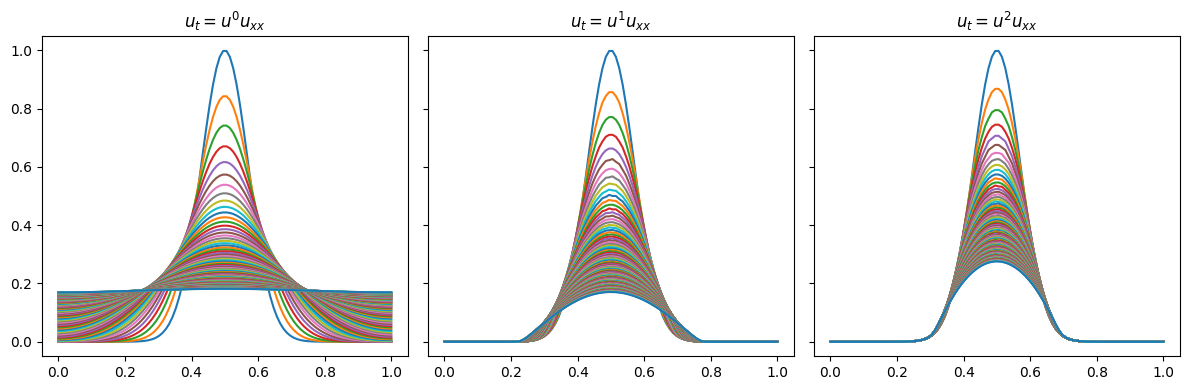

In [19]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, sharey = True, sharex = True, figsize = (12, 4))
for i, (ax, y) in enumerate(zip(axs.ravel(), [y_0, y_1, y_2])):
    ax.plot(x, y.y)
    ax.set_title(rf'$u_t=u^{i}u_{{xx}}$')
fig.tight_layout()
fig.show()

In [20]:
from utils.pde import PDE

pde_dxdxu_txt = 'D[2, 0, 0]'
pde_udxdxu_txt = 'u*D[2, 0, 0]'
pde_uudxdxu_txt = 'u*u*D[2, 0, 0]'

pde_dxdxu = PDE(pde_dxdxu_txt, equal_time_derivative = True)
pde_udxdxu = PDE(pde_udxdxu_txt, equal_time_derivative = True)
pde_uudxdxu = PDE(pde_uudxdxu_txt, equal_time_derivative = True)

In [39]:
from utils.triangulation import Triangulation
from utils.finite_element import LagrangeBasis, FiniteElement
from utils.tensor_network import TensorUnit, TensorNetwork
from utils.solver import DMRG

triangulation = Triangulation(np.linspace(0, 1, 11))
basis = LagrangeBasis(1, 3)

fe = FiniteElement(triangulation, basis)
fe.set_con_bc_operators(1)
fe.set_env_bc_operators({0: {1: ([np.array([[0]]), np.array([[[1]]])], 
                                  np.array([[0]]))},
                         9: {0: ([np.array([[0]]), np.array([[[1]]])], 
                                  np.array([[0]]))}})
fe.calculate_higher_domain_derivatives(2)

tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)
tn.set_u_shape(tuple())
tn.set_h_tensor_units([])

bond_order = 1
delta = 0.001

y0 = lambda x: np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)
rep = fe.fun2rep(y0)
rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

all_reps = [[states.tensor[..., 0, 0].copy()], [states.tensor[..., 0, 0].copy()], [states.tensor[..., 0, 0].copy()]]
for reps, pde in zip(all_reps, [pde_dxdxu, pde_udxdxu, pde_uudxdxu]):
    for i in range(100):
        pde_operators, pde_power =  tn.get_operators_from_pde(pde.pde, delta, states.copy())
        tn.set_states(states, bond_order)
        tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
        tn.set_solver(DMRG())
        tn.set_operators(pde_operators, pde_power)
        states = tn.solve(rounds = 20, alpha = 1, env = True)
        reps.append(states.tensor[..., 0, 0].copy())
    states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

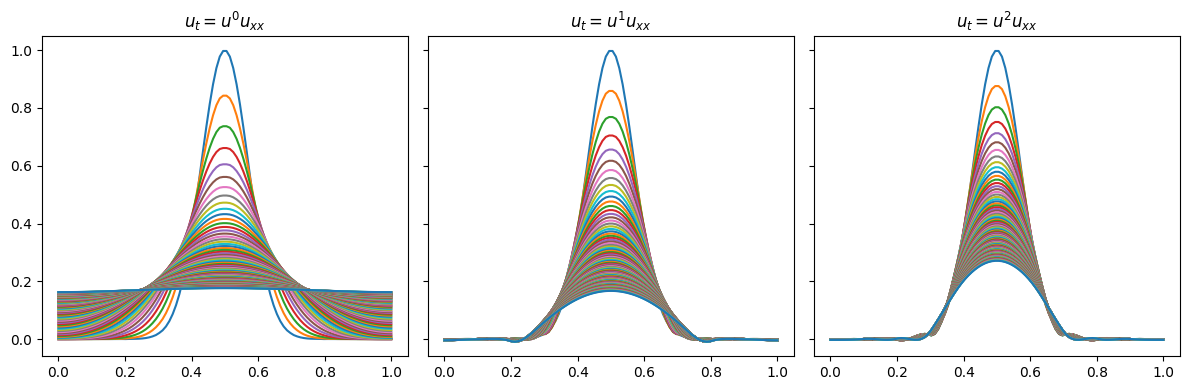

In [40]:
x = np.linspace(0, 1, 100)

fig, axs = plt.subplots(1, 3, sharey = True, sharex = True, figsize = (12, 4))
for i, (ax, reps) in enumerate(zip(axs.ravel(), all_reps)):
    for rep in reps:
        ax.plot(x, fe.rep2fun(rep)(x))
    ax.set_title(rf'$u_t=u^{i}u_{{xx}}$')
fig.tight_layout()
fig.show()

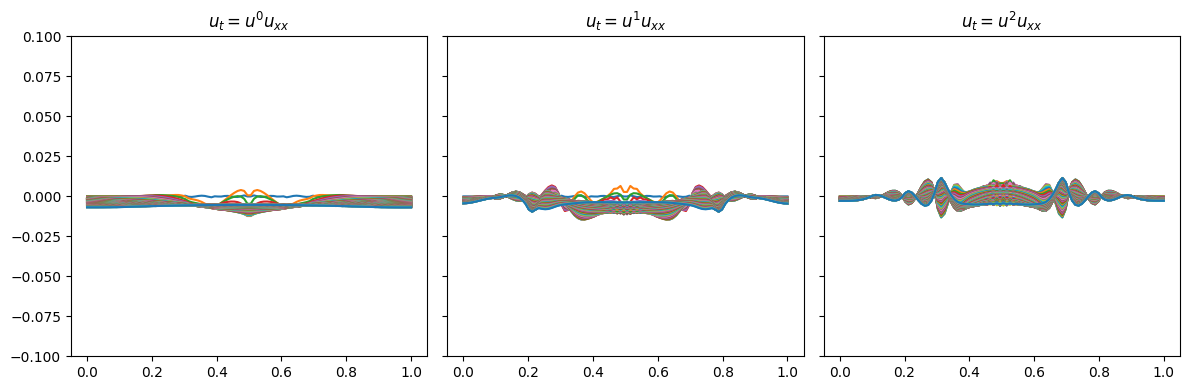

In [41]:
fig, axs = plt.subplots(1, 3, sharey = True, sharex = True, figsize = (12, 4))
for i, (ax, reps, y) in enumerate(zip(axs.ravel(), all_reps, [y_0, y_1, y_2])):
    for j, rep in enumerate(reps):
        dy = fe.rep2fun(rep)(x) - y.y[..., j]
        ax.plot(x, dy)
    ax.set_title(rf'$u_t=u^{i}u_{{xx}}$')
    ax.set_ylim(-0.1, 0.1)
fig.tight_layout()
fig.show()

In [72]:
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter

x = np.linspace(0, 1, 100)

fig, axs = plt.subplots(2, 3, sharex = True, sharey = 'row', height_ratios = [1, 0.25], gridspec_kw = {'hspace': 0.1}, figsize = (12, 5.2))

def animate(t):
    for ax in axs.ravel():
        ax.clear()
    
    for c, (reps, y)  in enumerate(zip(all_reps, [y_0, y_1, y_2])):
        y_nm = y.y[..., t]
        y_tn = fe.rep2fun(reps[t])(x)
        axs[0, c].plot(x, y_tn, '.C1', label = 'tensor network')
        axs[0, c].plot(x, y_nm, '-C0', label = 'normal Euler')

        axs[1, c].plot(x, y_tn - y_nm)

        axs[0, c].set_title(rf'$u_t = u^{c}u_{{xx}}$')
        axs[1, c].set_xlabel('x')
            
    axs[0, 0].legend(loc = 'upper left')
    axs[0, 0].set_xlim([0, 1])
    axs[0, 0].set_ylim([-0.05, 1.05])
    axs[0, 0].set_ylabel(r'$u$')
    axs[1, 0].set_ylim([-0.02, 0.02])
    axs[1, 0].set_ylabel(r'$\Delta u$')

    fig.suptitle('Non-Linear Diffusion Simulation')
    fig.subplots_adjust(hspace = None)

ani = FuncAnimation(fig, animate, frames = 101, interval = 500, repeat = False)
plt.close(fig)

ani.save('diffusion.gif', dpi = 300, writer = PillowWriter(fps = 10))